-------------

Vamos a empezar de nuevo con Daowa Maad, misma estructura, mismo todo, pero le añadiré un canal extra para que vea en frecuencias bajas y ver si realiza buenas, malas o pésimas predicciones

-------------

In [1]:
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
#                                           $
#  Importación de librerías                 $
#                                           $
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$

import timm
import os
import datetime
import cv2
import numpy as np
import torch
import pandas as pd
from typing import Any
from tqdm import tqdm
from torch import nn
from PIL import Image
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.transforms import InterpolationMode, functional

c:\Users\PC\Desktop\Abbadon\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
#
# Función para probar solamente el código con un modelo mío
#
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$

from utils.models.utils_med import TransformerDaowa_maad

def get_DaowaV2(pretrained_weights:bool = False):
    if pretrained_weights:
        daowa = TransformerDaowa_maad(num_clases=4)
        daowa.load_state_dict(torch.load('../Models/Daowa_maadWeights.pth', weights_only=True))
    else:
        daowa = TransformerDaowa_maad(num_clases=4)
    
    return daowa


In [3]:
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
#                                                            $
# Generación del dataset y aquí es donde ocurre la magia con $
# la descomposición de funciones de Fourier para imágenes    $
#                                                            $
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$

def get_fourier_lowpass(img_np, freq_radius):
    # Ya recibimos el array, no leemos disco otra vez
    h, w = img_np.shape
    f = np.fft.fft2(img_np)
    fshift = np.fft.fftshift(f)

    mask = np.zeros((h, w), np.float32)
    cy, cx = h // 2, w // 2
    cv2.circle(mask, (cx, cy), freq_radius, 1, -1)

    fshift_filtered = fshift * mask
    img_lowpass = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift_filtered)))
    
    # Normalizamos a 0-1 para que coincida con ToTensor()
    return img_lowpass / 255.0

class CusDataset(Dataset):
    def __init__(self, dataframe, images_dir, masks_dir, images_transform=None, mask_transform = None, shape_img = tuple):
        self.df = dataframe #This is a Dataframe from Pandas
        self.img_dir = images_dir
        self.masks_dir = masks_dir
        self.shape = shape_img
        if images_transform:
            self.img_trans = images_transform
        else:
            self.img_trans = transforms.Compose([
                transforms.Resize((self.shape), interpolation=InterpolationMode.BILINEAR),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean = [0.4811, 0.4491, 0.3961],
                    std = [0.2634, 0.2587, 0.2667]
                )
            ])
        self.mask_transform = mask_transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, index):
        img_filename = self.df.iloc[index, 0]
        mask_filename = self.df.iloc[index, 1]

        img_dir = os.path.join(self.img_dir, img_filename)
        mask_dir = os.path.join(self.masks_dir, mask_filename)

        img = Image.open(img_dir).convert(mode='RGB').resize(self.shape)
        img_fourier_np = np.array(img.convert('L'))

        img_lowpass = get_fourier_lowpass(img_fourier_np, 50)
        img_tensor_lowpass = torch.from_numpy(img_lowpass).unsqueeze(0).float()
        
        
        mask = Image.open(mask_dir)

        img = self.img_trans(img)
        mask = functional.resize(mask, (self.shape), InterpolationMode.NEAREST)

        mask_np = np.array(mask)
        mask_tensor = torch.from_numpy(mask_np).long()
        mask_tensor = torch.clamp(mask_tensor, 0, 2)

        img = torch.cat((img, img_tensor_lowpass))
        return img, mask_tensor

In [4]:
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
#                                                                            $
# Función de predicción                                                      $
#                                                                            $
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$

def predict_image(model, image, device):
    model.to(device)
    model.eval()
    with torch.no_grad():
        image = image.to(device)
        output = model(image)
        _, preds = torch.max(output, 1)
    return preds



In [5]:
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
#                                                             $
#   Codificación de la función de pérdida GeneralizedDiceLoss $
#                                                             $
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$

class GeneralizedDiceLossFN(nn.Module):
    def __init__(self, epsilon, target_classes):
        super(GeneralizedDiceLossFN, self).__init__()
        self.epsilon:float = epsilon
        self.target_classes:int = target_classes

    def forward(self, inTensor:torch.Tensor, target:torch.Tensor):

        """
        Attributes:
            - Input: Es el vector de entrada donde contiene los logits de la predicción, con shape = [Batch, N_clases, H, W]
            - Target: Es el tensor objetivo, donde se tiene que acercar, con shape = [Batch, H, W]
        """
        input = F.softmax(input=inTensor, dim = 1)
        input = input.view(input.size(0), input.size(1), -1).float()

        target = F.one_hot(target, self.target_classes).permute(0, 3, 1, 2).float()

        volumenes = torch.sum(target, dim = (2, 3))
        w_c = 1 / (volumenes ** 2 + self.epsilon)

        target = target.view(target.size(0), target.size(1), -1).float()

        interseccion = torch.sum(input * target, dim = 2)
        union = torch.sum(input + target, dim = 2)

        numerador = torch.sum(w_c * interseccion, dim = 1)
        denominador = torch.sum(w_c * union, dim = 1)

        out = 1 - (2 * (numerador / (denominador + self.epsilon)))
        
        return out.mean()



In [6]:
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
#                                                              &
#  Codificación de la métrica de precisión IoU                 $
#                                                              &
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$


def IoU_global(intersection:torch.Tensor, union:torch.Tensor, smooth = 1e-6):
    
    IoU_por_clase:torch.Tensor = (intersection + smooth) / (union + smooth)
    
    IoU_global:torch.Tensor = torch.mean(IoU_por_clase)

    return IoU_global, IoU_por_clase

def meanIoU(y_pred:torch.Tensor, y_true:torch.Tensor, num_classes:int, smooth:float = 1e-6):

    y_pred = torch.argmax(y_pred, dim = 1)

    IoU_clase:list[Any] = []

    for i in range(0, num_classes):
        pred_i = (y_pred == i).to(torch.float32)
        true_i = (y_true == i).to(torch.float32)

        interseccion = torch.sum(pred_i * true_i)
        union = torch.sum(pred_i) + torch.sum(true_i) - interseccion #PRINCIPIO DE INCLUSIÓN-EXCLUSIÓN

        iou = (interseccion + smooth) / (union + smooth)
        IoU_clase.append(iou)
    
    if len(IoU_clase) == 0:
        return torch.tensor(0.0, device=y_pred.device)
    
    return torch.mean(torch.stack(IoU_clase))

def get_intersections_and_unions(y_pred:torch.Tensor, y_true:torch.Tensor, class_id:int | Any):

    y_pred = (y_pred == class_id).to(torch.float32)
    y_true = (y_true == class_id).to(torch.float32)

    intersection = torch.sum(y_pred * y_true)
    union = torch.sum(y_pred) + torch.sum(y_true) - intersection

    return  (intersection, union)

In [30]:
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
#                                                                                $
#   Función de entrenamiento del modelo                                          $
#                                                                                $
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$

from torch.utils.tensorboard import SummaryWriter

# Entrenamiento con Bfloat16 (Prueba)

def train_model(modelo, loss_fn, optimizador, dataloaders:list, device_calc, scheduler = None):

    dia = datetime.date.today()
    writer = SummaryWriter(fr'logs/tensorboard/daowa_maad_v3_{dia}')

    if modelo and isinstance(dataloaders, list):
        
        modelo.to(device_calc)

        #Desempaquetado

        cross_fn, dice_fn = loss_fn

        train_dl, val_dl, _ = dataloaders
        
        #Métricas
        epochs = 20
        best_iou = 0.0

        print("Iniciando entrenamiento")

        for i in tqdm(range(1, epochs + 1), desc=f"Entrenando el modelo"):
            if 0 < i <= 5:
                #Métricas
                peso_dice = 0
                peso_cross = 1
            
            elif 5 < i <= 10: 
                #Métricas
                peso_dice = 0.5
                peso_cross = 0.5
            
            elif 10 < i <= 20:
                #Métricas
                peso_dice = 0.8
                peso_cross = 0.2
            
            #Métricas
            train_loss_acc = 0.0
            train_correct_pixels = 0
            train_total_pixels = 0
            intersections = torch.zeros(3, device=device_calc)
            unions = torch.zeros(3, device=device_calc)

            #Modelo en modo de entrenamiento wachin
            modelo.train()
            for image, mask in train_dl:
                image, mask = image.to(device_calc), mask.to(device_calc)

                optimizador.zero_grad()
                with torch.amp.autocast_mode.autocast(device_type="cuda", dtype=torch.bfloat16):
                    output = modelo(image) # [Batch, 3, 512, 512]
                
                    loss_cross = cross_fn(output, mask)
                    loss_dice = dice_fn(output, mask) # Mask debe ser [Batch, 512, 512] (Long)
                    total_loss = (peso_cross * loss_cross + peso_dice * loss_dice)
                
                total_loss.backward()
                optimizador.step()

                train_loss_acc += total_loss.item()
                
                # Precisión de Píxeles (Train)
                _, preds = torch.max(output, 1) # Obtenemos el índice de la clase ganadora
                train_correct_pixels += (preds == mask).sum().item()
                train_total_pixels += mask.numel() # Total de píxeles en el batch

            train_loss = train_loss_acc / len(train_dl)
            train_acc = (train_correct_pixels / train_total_pixels) * 100

            #Ya nomás pa' evaluar
            actual_valLoss = 0.0
            val_correct_pixels = 0
            val_total_pixels = 0

            modelo.eval()
            with torch.no_grad():
                for image, mask in val_dl:
                    image = image.to(device_calc)
                    mask = mask.to(device_calc)
                    
                    #Predicción
                    predict = modelo(image)
                
                    _y_predicts = torch.argmax(predict, dim = 1)

                    inter_0, union_0 = get_intersections_and_unions(_y_predicts, mask, 0)
                    inter_1, union_1 = get_intersections_and_unions(_y_predicts, mask, 1)
                    inter_2, union_2 = get_intersections_and_unions(_y_predicts, mask, 2)

                    inters = torch.stack([inter_0, inter_1, inter_2])
                    unis = torch.stack([union_0, union_1, union_2])

                    intersections += inters
                    unions += unis

                    cross_loss = cross_fn(predict, mask)
                    dice_loss = dice_fn(predict, mask)
                    val_loss = (peso_cross * cross_loss + peso_dice * dice_loss)

                    #Acumular loss
                    actual_valLoss += val_loss.item()

                    _, predicts = torch.max(predict, 1) #Acá podes ver la confianza de predicción con confianza en lugar de _

                    val_correct_pixels += (predicts == mask).sum().item()
                    val_total_pixels += mask.numel()

            avg_val_loss = actual_valLoss / len(val_dl)
            val_acc = (val_correct_pixels / val_total_pixels) * 100
            mIoU, IoU_por_clase = IoU_global(intersections, unions)
            IoU_por_clase = IoU_por_clase.cpu().numpy().tolist()

            # Uso de TensorBoard para graficar las métricas y verlas en tiempo real

            #Loss
            writer.add_scalars('Loss', {                          
                'train': train_loss,                              
                'val': avg_val_loss                               
            }, i)       

            # Accuracy
            writer.add_scalars('Pixel Accuracy', {                
                'train': train_acc,                               
                'val': val_acc                                    
            }, i)             

            # IoU
            writer.add_scalar('mIoU Global', mIoU, i)            
            writer.add_scalars('IoU por Clase', {                 
                'Mascota': IoU_por_clase[0],                      
                'Fondo': IoU_por_clase[1],                        
                'Borde': IoU_por_clase[2]                         
            }, i)        

            # Learning Rate
            writer.add_scalar('Learning Rate',                    
                optimizador.param_groups[0]['lr'], i)   
            
            # Pesos de loss (para trackear tu schedule)
            writer.add_scalars('Loss Weights', {                  
                'cross': peso_cross,                              
                'dice': peso_dice                                 
            }, i) 

            if scheduler:
                if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                    scheduler.step(avg_val_loss)
                else:
                    scheduler.step()
            
            if mIoU > best_iou:
                torch.save(modelo.state_dict(), fr'../Models/ModeloPrueba{dia}.pth')
                best_iou = mIoU
                print(f"--> Nuevo mejor modelo con acc: {best_iou:.2f}")

            fila_csv = {
                "train_loss":train_loss,
                "train_acc":train_acc, 
                "val_loss":avg_val_loss,
                "val_acc":val_acc,
                "val_iou Global":mIoU,
                "val_iou Clases":IoU_por_clase
                }
            
            df = pd.DataFrame([fila_csv])
            df.to_csv(fr'logs/training_history{dia}.csv',
                        mode='a', 
                        header=not os.path.exists(fr'logs/training_history{dia}.csv'),
                        index=False)

            print(f"Epoch {i}: Train Loss = {train_loss:.4f}; Precision = {train_acc:.4f}; Validation loss = {avg_val_loss:.4f}, Precisión = {val_acc:.4f}%, IoU Global = {mIoU:.4f}, IoU Clase [Mascota, Fondo, Borde] = {IoU_por_clase}")
    
    writer.close()
    return "Entrenamiento completado"

In [8]:
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
#                                                              &
#  Codificación de Attention Gates para filtrar contexto local $
#                                                              &
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$

class AttentionGates(nn.Module):
    def __init__(self, f_g, f_l, F_int):
        super(AttentionGates, self).__init__()

        self.w_x = nn.Sequential(
            nn.Conv2d(f_l, F_int, kernel_size= 3, stride = 2, padding = 1, bias = False),
            nn.BatchNorm2d(F_int, affine=True)
        )

        self.w_g = nn.Sequential(
            nn.Conv2d(f_g, F_int, kernel_size=3, stride=2, padding = 1, bias = False),
            nn.BatchNorm2d(F_int, affine = True)
        )
        
        self.psi = nn.Sequential(
            nn.Conv2d(in_channels = F_int, out_channels=1, kernel_size=1, stride = 1, padding = 0, bias = False),
            nn.BatchNorm2d(1, affine = tri)
        )

        self.relu = nn.ReLU(inplace=True)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, gating, skip):
        g = self.w_g(gating)
        s = self.w_x(skip)

        if g.shape[2:] != s.shape[2:]:
            g = torch.nn.functional.interpolate(g, size = s.shape[2:], mode='NEAREST')

        relu = self.relu(g + s)
        psi = self.psi(relu)
        sigmoid = self.sigmoid(psi)
        out = torch.nn.functional.interpolate(sigmoid, size = s.shape[2:], mode = 'bilinear', align_corners=True)
        
        return out

In [10]:
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
#
# Arquitectura Daowa_maad sin transformers
# después se le agregará el transformer
# para comparar el rendimiento
#
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$


from utils.models.blocks import UpSampling, AttentionGates

class Daowa_maadPrueba(nn.Module):
    def __init__(self, num_clases = 3):
        super(Daowa_maadPrueba, self).__init__()

        self.encoder = timm.create_model(
            'convnextv2_tiny.fcmae_ft_in22k_in1k',
            pretrained=True,
            features_only=True,
            out_indices=[0, 1, 2, 3]
        ) # Salida de 768 filtros o canales

        old_conv = self.encoder.stem_0
        new_conv = nn.Conv2d(4, old_conv.out_channels, kernel_size=old_conv.kernel_size, stride=old_conv.stride, padding=old_conv.padding, bias=old_conv.bias is not None)

        with torch.no_grad():
            new_conv.weight.data[:, :3, :, :] = old_conv.weight.data
            new_conv.weight.data[:, 3:, :, :] = old_conv.weight.data[:, 0:1, :, :]

        self.encoder.stem_0 = new_conv


        self.att_gate1 = AttentionGates(768, 384, 384)
        self.att_gate2 = AttentionGates(384, 192, 192)
        self.att_gate3 = AttentionGates(192, 96, 96)

        self.up1 = UpSampling(768, 384)
        self.up2 = UpSampling(384, 192)
        self.up3 = UpSampling(192, 96)

        self.head = nn.Conv2d(96, num_clases, kernel_size=1)


    def forward(self, x):
        input_size = x.shape[2:]

        x1, x2, x3, x4 = self.encoder(x)
        # x1=[96,48,48], x2=[192,24,24], x3=[384,12,12], x4=[768,6,6]

        x3_filtrada = self.att_gate1(x4, x3)
        x = self.up1(x4, x3_filtrada)
        
        x2_filtrada = self.att_gate2(x, x2)
        x = self.up2(x, x2_filtrada)

        x1_filtrada = self.att_gate3(x, x1)
        x = self.up3(x, x1_filtrada)

        logits = self.head(x)
        logits = F.interpolate(logits, size=input_size, mode='bilinear', align_corners=True)
        return logits


In [11]:
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
#
# Prueba de la arquitectura y corroborar su salida
#
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Daowa_maadPrueba(num_clases=3)
model.to(device)
x = torch.randn(2, 4, 192, 192).to(device)
out = model(x)
print(out.shape)

torch.Size([2, 3, 192, 192])


In [12]:
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
#
# Obtención de parámetros para el optimizador
# con esto tener diferente tasa de aprendizaje
# para el encoder y el decoder
#
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$

encoder_params = list(model.encoder.parameters())
print(len(encoder_params))
encoder_ids = set(id(p) for p in encoder_params)
print(len(encoder_ids))
decoder_params = [p for p in model.parameters() if id(p) not in encoder_ids]
print(len(decoder_params))

optimizer = torch.optim.AdamW([
    {'params': encoder_params, 'lr': 1e-5},   # Pre-trained → LR bajo
    {'params': decoder_params, 'lr': 1e-4},    # Tu decoder → LR normal
])

196
196
65


In [13]:
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
#                                                                                $
#   Generación del dataset y así mismo                                           $
#                                                                                $
#   División del dataset en entrenamiento, validación y prueba                   $
#                                                                                $
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$

from sklearn.model_selection import train_test_split

def get_dataloaders(batch_size=32, shuffle=True, num_workers=4, pin_memory=True):
    df = pd.read_csv("labels/dataset_daowaV2.csv")
    train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
    val_df, test_df = train_test_split(val_df, test_size=0.1, random_state=42)

    train_ds = CusDataset(train_df, "data/image/images", "data/image/masks", shape_img=(192, 192))
    val_ds = CusDataset(val_df, "data/image/images", "data/image/masks", shape_img=(192, 192))
    test_ds = CusDataset(test_df, "data/image/images", "data/image/masks", shape_img=(192, 192))

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=shuffle, num_workers=num_workers, pin_memory=pin_memory)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=shuffle, num_workers=num_workers, pin_memory=pin_memory)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=shuffle, num_workers=num_workers, pin_memory=pin_memory)
    return [train_loader, val_loader, test_loader]

In [14]:
losses = [nn.CrossEntropyLoss(), GeneralizedDiceLossFN(epsilon=1e-6, target_classes=3)]
dataloaders = get_dataloaders(batch_size=16, shuffle=False, num_workers=0, pin_memory=True)

print(type(dataloaders))
device_calc = torch.device("cuda" if torch.cuda.is_available() else "cpu")
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

train_model(model, losses, optimizer, dataloaders, device_calc, scheduler)

<class 'list'>
Iniciando entrenamiento


Entrenando el modelo:   5%|▌         | 1/20 [00:45<14:31, 45.87s/it]

--> Nuevo mejor modelo con acc: 0.64
Epoch 1: Train Loss = 0.5207; Precision = 79.0639; Validation loss = 0.3851, Precisión = 85.0542%, IoU Global = 0.6443, IoU Clase [Mascota, Fondo, Borde] = [0.7110392451286316, 0.8391143679618835, 0.3827429711818695]


Entrenando el modelo:  10%|█         | 2/20 [01:27<12:58, 43.24s/it]

--> Nuevo mejor modelo con acc: 0.67
Epoch 2: Train Loss = 0.3408; Precision = 86.8215; Validation loss = 0.3485, Precisión = 86.5244%, IoU Global = 0.6690, IoU Clase [Mascota, Fondo, Borde] = [0.7348753213882446, 0.8507688045501709, 0.4214591383934021]


...

Entrenando el modelo:  95%|█████████▌| 19/20 [13:20<00:41, 41.42s/it]

Epoch 19: Train Loss = 0.1519; Precision = 95.4224; Validation loss = 0.2526, Precisión = 91.7597%, IoU Global = 0.7748, IoU Clase [Mascota, Fondo, Borde] = [0.849062442779541, 0.9192503690719604, 0.5559924840927124]


Entrenando el modelo: 100%|██████████| 20/20 [14:02<00:00, 42.12s/it]

Epoch 20: Train Loss = 0.1487; Precision = 95.5238; Validation loss = 0.2531, Precisión = 91.7880%, IoU Global = 0.7749, IoU Clase [Mascota, Fondo, Borde] = [0.8503001928329468, 0.9201376438140869, 0.5543251037597656]


'Entrenamiento completado'

In [22]:
import matplotlib.pyplot as plt

def postprocessMask(out_network, kernel:int):
    """
    Args:
        - out_network: Salida de la red neuronal, en este caso Daowa-Maad. Con la forma: [Batch, Channels, Height, Weight]

        - kernel: El tamaño 'pincel' por así decirlo, siempre tiene que ser impar por mera geometría matemática, además de que si el número es muy alto, puedes perder detalles finos.
    """
    if torch.is_tensor(out_network) and (kernel % 2 != 0):
        #Primero tenemos que convertir esa máscara a un arreglo de NumPy para CV2

        #> Aquí primero debemos quitarle el espía al tensor, para que PyTorch deje de rastrearlo y esto se usa para el AutoGrad, pero en este caso no lo ocupamos
        out_network = out_network.detach()

        #AHORA debemos bajarlo de la CPU
        print(out_network.device) #Saldrá device(type='cuda', index=0)

        out_network = out_network.cpu()
        print(out_network.device)

        #Ahora debemos quitar los canales, pues a ver... vamo' a hacerle un poco de ingeniería inversa pq hace 2 semanas no toco este código JAJAJ

        """
        Vale, ya entendí, devuelve 3 canales (son 3 laminas en un cubo, básicamente...) que son una para el fondo, el animal y el borde, así que podemos usar torch.argmax para colapsar columnas
        """
        out_network = torch.argmax(out_network, dim = 1)
        print(out_network.shape) #torch.Size([1, 192, 192])

        #Ahora usaremos squeeze para quitar el 1 al final y ahora si que funcione CV2
        indices = out_network.squeeze(0)

        mascara_animal = (indices == 0).numpy()
        mascara_uint8 = (mascara_animal * 255).astype(np.uint8)

        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel, kernel))
        mask_limpia = cv2.morphologyEx(mascara_uint8, cv2.MORPH_OPEN, kernel)
        
        print(mask_limpia.size)

        return indices.numpy(), mask_limpia

def prediccionPrueba(modelo, dir_path:str, img_dir:str, device):
    img_path = os.path.join(dir_path, img_dir)
    img_open = Image.open(img_path).convert('RGB').resize((192, 192))
    
    # Canal Fourier (igual que en tu CusDataset)
    img_fourier_np = np.array(img_open.convert('L'))
    img_lowpass = get_fourier_lowpass(img_fourier_np, 50)
    img_tensor_lowpass = torch.from_numpy(img_lowpass).unsqueeze(0).float()
    
    tf = transforms.Compose([
        transforms.Resize((192, 192)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std = [0.229, 0.224, 0.225])
    ])
    img = tf(img_open)
    
    # Concatenar RGB (3) + Fourier (1) = 4 canales
    img = torch.cat((img, img_tensor_lowpass), dim=0)

    img = img.to(device)
    img = img.unsqueeze(0)
    modelo = modelo.to(device)
    modelo.eval()
    with torch.no_grad():
        output = modelo(img)
    
    indices, mascara = postprocessMask(output, kernel = 5)

    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    
    # A) Imagen Original
    ax[0].imshow(img_open)
    ax[0].set_title("Input Original")
    ax[0].axis('off')
    
    # B) Salida Cruda de la Red (Multiclase)
    cax = ax[1].imshow(indices, cmap='jet', vmin=0, vmax=2)
    ax[1].set_title("Red Neuronal (Crudo)")
    ax[1].axis('off')
    cbar = plt.colorbar(cax, ax=ax[1], ticks=[0, 1, 2], fraction=0.046, pad=0.04)
    cbar.ax.set_yticklabels(['Mascota (0)', 'Fondo(1)', 'Borde (2)']) 
    
    # C) Salida Limpia (CV2)
    ax[2].imshow(mascara, cmap='gray')
    ax[2].set_title("Post-Proceso")
    ax[2].axis('off')
    
    plt.tight_layout()
    plt.show()

    return output

cuda:0
cpu
torch.Size([1, 192, 192])
36864


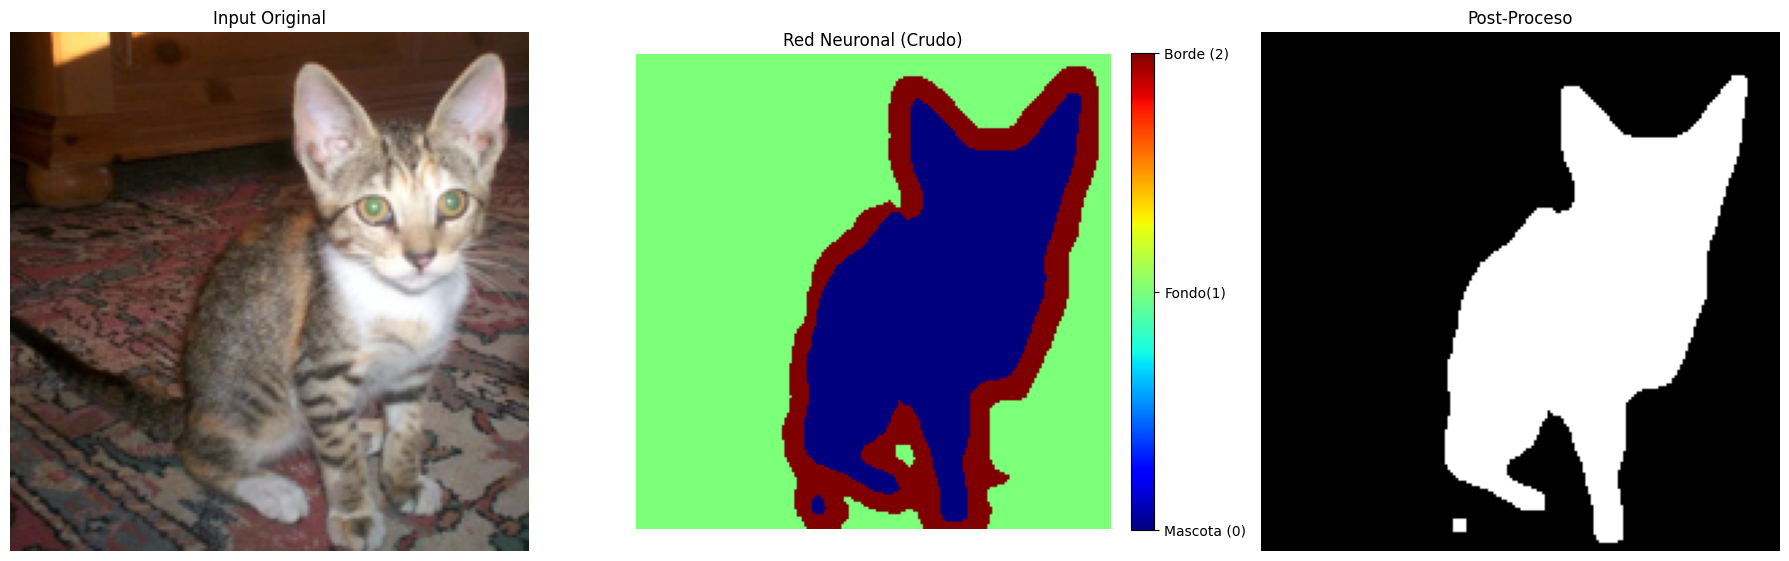

tensor([[[[-8.0192, -7.4484, -6.8777,  ..., -6.2119, -6.1708, -6.1297],
          [-7.4842, -6.9537, -6.4232,  ..., -6.2332, -6.1623, -6.0913],
          [-6.9493, -6.4590, -5.9687,  ..., -6.2545, -6.1537, -6.0530],
          ...,
          [-7.7895, -7.2150, -6.6405,  ..., -6.7660, -7.4327, -8.0994],
          [-8.1023, -7.5588, -7.0153,  ..., -7.1604, -8.0530, -8.9456],
          [-8.4150, -7.9026, -7.3902,  ..., -7.5547, -8.6733, -9.7918]],

         [[ 3.7735,  3.7059,  3.6383,  ...,  4.9833,  4.7794,  4.5755],
          [ 3.7974,  3.8891,  3.9808,  ...,  5.3150,  5.2490,  5.1831],
          [ 3.8212,  4.0722,  4.3233,  ...,  5.6467,  5.7187,  5.7907],
          ...,
          [ 5.5724,  5.5680,  5.5636,  ...,  5.2406,  5.5203,  5.7999],
          [ 5.5914,  5.6066,  5.6218,  ...,  5.1365,  5.4944,  5.8523],
          [ 5.6105,  5.6453,  5.6801,  ...,  5.0323,  5.4685,  5.9047]],

         [[-0.1172, -0.3926, -0.6680,  ..., -2.6113, -2.8951, -3.1789],
          [-0.6572, -1.2193, -

In [25]:
prediccionPrueba(model, 'data/petimages/cat', "7.jpg", device_calc)

------------------------------------------------------------------

Ahora haremos un modelo con aumentación de datos, con transformer encoder en el bottleneck y fine tuning

In [9]:

#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
#                                                              &
#  Codificación de un Transformer encoder para contexto global $
#                                                              &
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$


class EncoderTrans(nn.Module):
    def __init__(self, in_embed_dim, _num_heads, _bias, _batch_first):

        """
        Attributes:
            - in_embed_dim: Dimensiones de entrada, es decir, los canales de la imagen en el bottleneck
            - _num_heads: Número de cabezas de atención múltiple
            - _bias: Booleano para saber si se aplica o no un sesgo al módulo MultiheadAttention
            - _batch_first: Booleano para decirle al módulo: 'Oye, el primer elemento del tensor es el batch'
        """

        super(EncoderTrans, self).__init__()
        self.mha = nn.MultiheadAttention(
                in_embed_dim,
                _num_heads, 
                dropout = 0.2, 
                bias = _bias, 
                batch_first=_batch_first
            )
        self.normalization_layer = nn.RMSNorm(in_embed_dim)
        self.ffn= nn.Sequential(
            nn.Linear(in_features=in_embed_dim, out_features=in_embed_dim * 4),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(in_features=in_embed_dim * 4, out_features=in_embed_dim),
            nn.Dropout(0.2)
        )
    
    def forward(self, x):
        norm_x = self.normalization_layer(x)
        out_mha, _ = self.mha(norm_x, norm_x, norm_x)
        x = out_mha + x

        norm_x = self.normalization_layer(x)
        out_ffn = self.ffn(norm_x)
        x = x + out_ffn

        return x


In [34]:
class Daowa_maadPrueba2(nn.Module):
    def __init__(self, num_clases):
        super(Daowa_maadPrueba2, self).__init__()

        self.encoder = timm.create_model(
            'convnextv2_tiny.fcmae_ft_in22k_in1k',
            pretrained=True,
            features_only=True,
            out_indices=[0, 1, 2, 3]
        ) # Salida de 768 filtros o canales

        old_conv = self.encoder.stem_0
        new_conv = nn.Conv2d(4, old_conv.out_channels, kernel_size=old_conv.kernel_size, stride=old_conv.stride, padding=old_conv.padding, bias=old_conv.bias is not None)

        with torch.no_grad():
            new_conv.weight.data[:, :3, :, :] = old_conv.weight.data
            new_conv.weight.data[:, 3:, :, :] = old_conv.weight.data[:, 0:1, :, :]

        self.encoder.stem_0 = new_conv

        self.transformer_encoder = EncoderTrans(in_embed_dim=768, _num_heads=12, _bias=True, _batch_first=True)
        self.pos_embedding = nn.Parameter(torch.randn(1, 36, 768))

        self.att_gate1 = AttentionGates(768, 384, 384)
        self.att_gate2 = AttentionGates(384, 192, 192)
        self.att_gate3 = AttentionGates(192, 96, 96)

        self.up1 = UpSampling(768, 384)
        self.up2 = UpSampling(384, 192)
        self.up3 = UpSampling(192, 96)

        self.head = nn.Conv2d(96, num_clases, kernel_size=1)
    
    def interpolate_pos_embed(self, x):
        B, N, C = x.shape
        origin_N = self.pos_embedding.shape[1]
        if N == origin_N:
            return self.pos_embedding
        
        orig_size = int(origin_N ** 0.5)
        new_size = int(N ** 0.5)
        
        pos_embed = self.pos_embedding.view(1, orig_size, orig_size, C).permute(0, 3, 1, 2) # [B, 6, 6, C] -> [B, C, 6, 6]
        pos_embed = F.interpolate(pos_embed, size=(new_size, new_size), mode='bicubic', align_corners=False) # [B, C, new_size, new_size]
        pos_embed = pos_embed.flatten(2).permute(0, 2, 1) # [B, new_size*new_size, C]
        return pos_embed
        

    def forward(self, x):
        input_size = x.shape[2:]

        x1, x2, x3, x4 = self.encoder(x)
        # x1=[96,48,48], x2=[192,24,24], x3=[384,12,12], x4=[768,6,6]

        B, C, H, W = x4.shape

        x4 = x4.view(B, C, -1).permute(0, 2, 1)
        x4 = self.transformer_encoder(x4 + self.interpolate_pos_embed(x4))
        x4 = x4.permute(0, 2, 1).view(B, C, H, W)

        x3_filtrada = self.att_gate1(x4, x3)
        x = self.up1(x4, x3_filtrada)
        
        x2_filtrada = self.att_gate2(x, x2)
        x = self.up2(x, x2_filtrada)

        x1_filtrada = self.att_gate3(x, x1)
        x = self.up3(x, x1_filtrada)

        logits = self.head(x)
        logits = F.interpolate(logits, size=input_size, mode='bilinear', align_corners=True)
        return logits


**Nota**: Por recomendación de Antigravity, he decidido poner un método para código dinámico en la clase Daowa_maadV3 para la creación del número de tokens en el modelo con Transformer encoder.

In [35]:
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
#                                                                                $
#   Función de entrenamiento del modelo                                          $
#                                                                                $
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$

# Entrenamiento con Bfloat16 (Prueba 2)

def train_model_2(modelo, loss_fn, optimizador, dataloaders:list, device_calc, scheduler = None):

    dia = datetime.date.today()
    writer = SummaryWriter(fr'logs/tensorboard/daowa_maad_v3_{dia}_2')

    if modelo and isinstance(dataloaders, list):
        
        modelo.to(device_calc)

        #Desempaquetado

        cross_fn, dice_fn = loss_fn

        train_dl, val_dl, _ = dataloaders
        
        #Métricas
        epochs = 20
        best_iou = 0.0

        print("Iniciando entrenamiento")

        for i in tqdm(range(1, epochs + 1), desc=f"Entrenando el modelo"):
            if 0 < i <= 5:
                #Métricas
                peso_dice = 0
                peso_cross = 1
            
            elif 5 < i <= 10: 
                #Métricas
                peso_dice = 0.5
                peso_cross = 0.5
            
            elif 10 < i <= 20:
                #Métricas
                peso_dice = 0.8
                peso_cross = 0.2
            
            #Métricas
            train_loss_acc = 0.0
            train_correct_pixels = 0
            train_total_pixels = 0
            intersections = torch.zeros(3, device=device_calc)
            unions = torch.zeros(3, device=device_calc)

            #Modelo en modo de entrenamiento wachin
            modelo.train()
            for image, mask in train_dl:
                image, mask = image.to(device_calc), mask.to(device_calc)

                optimizador.zero_grad()
                with torch.amp.autocast_mode.autocast(device_type="cuda", dtype=torch.bfloat16):
                    output = modelo(image) # [Batch, 3, 512, 512]
                
                    loss_cross = cross_fn(output, mask)
                    loss_dice = dice_fn(output, mask) # Mask debe ser [Batch, 512, 512] (Long)
                    total_loss = (peso_cross * loss_cross + peso_dice * loss_dice)
                
                total_loss.backward()
                optimizador.step()

                train_loss_acc += total_loss.item()
                
                # Precisión de Píxeles (Train)
                _, preds = torch.max(output, 1) # Obtenemos el índice de la clase ganadora
                train_correct_pixels += (preds == mask).sum().item()
                train_total_pixels += mask.numel() # Total de píxeles en el batch

            train_loss = train_loss_acc / len(train_dl)
            train_acc = (train_correct_pixels / train_total_pixels) * 100

            #Ya nomás pa' evaluar
            actual_valLoss = 0.0
            val_correct_pixels = 0
            val_total_pixels = 0

            modelo.eval()
            with torch.no_grad():
                for image, mask in val_dl:
                    image = image.to(device_calc)
                    mask = mask.to(device_calc)
                    
                    #Predicción
                    predict = modelo(image)
                
                    _y_predicts = torch.argmax(predict, dim = 1)

                    inter_0, union_0 = get_intersections_and_unions(_y_predicts, mask, 0)
                    inter_1, union_1 = get_intersections_and_unions(_y_predicts, mask, 1)
                    inter_2, union_2 = get_intersections_and_unions(_y_predicts, mask, 2)

                    inters = torch.stack([inter_0, inter_1, inter_2])
                    unis = torch.stack([union_0, union_1, union_2])

                    intersections += inters
                    unions += unis

                    cross_loss = cross_fn(predict, mask)
                    dice_loss = dice_fn(predict, mask)
                    val_loss = (peso_cross * cross_loss + peso_dice * dice_loss)

                    #Acumular loss
                    actual_valLoss += val_loss.item()

                    _, predicts = torch.max(predict, 1) #Acá podes ver la confianza de predicción con confianza en lugar de _

                    val_correct_pixels += (predicts == mask).sum().item()
                    val_total_pixels += mask.numel()

            avg_val_loss = actual_valLoss / len(val_dl)
            val_acc = (val_correct_pixels / val_total_pixels) * 100
            mIoU, IoU_por_clase = IoU_global(intersections, unions)
            IoU_por_clase = IoU_por_clase.cpu().numpy().tolist()

            # Uso de TensorBoard para graficar las métricas y verlas en tiempo real

            #Loss
            writer.add_scalars('Loss', {                          
                'train': train_loss,                              
                'val': avg_val_loss                               
            }, i)       

            # Accuracy
            writer.add_scalars('Pixel Accuracy', {                
                'train': train_acc,                               
                'val': val_acc                                    
            }, i)             

            # IoU
            writer.add_scalar('mIoU Global', mIoU, i)            
            writer.add_scalars('IoU por Clase', {                 
                'Mascota': IoU_por_clase[0],                      
                'Fondo': IoU_por_clase[1],                        
                'Borde': IoU_por_clase[2]                         
            }, i)        

            # Learning Rate
            writer.add_scalar('Learning Rate',                    
                optimizador.param_groups[0]['lr'], i)   
            
            # Pesos de loss (para trackear tu schedule)
            writer.add_scalars('Loss Weights', {                  
                'cross': peso_cross,                              
                'dice': peso_dice                                 
            }, i) 

            if scheduler:
                if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                    scheduler.step(avg_val_loss)
                else:
                    scheduler.step()
            
            if mIoU > best_iou:
                torch.save(modelo.state_dict(), fr'../Models/ModeloPrueba{dia}.pth')
                best_iou = mIoU
                print(f"--> Nuevo mejor modelo con mIoU: {best_iou:.2f}")

            fila_csv = {
                "train_loss":train_loss,
                "train_acc":train_acc, 
                "val_loss":avg_val_loss,
                "val_acc":val_acc,
                "val_iou Global":mIoU,
                "val_iou Clases":IoU_por_clase
                }
            
            df = pd.DataFrame([fila_csv])
            df.to_csv(fr'logs/training_history{dia}_2.csv',
                        mode='a', 
                        header=not os.path.exists(fr'logs/training_history{dia}_2.csv'),
                        index=False)

            print(f"Epoch {i}: Train Loss = {train_loss:.4f}; Precision = {train_acc:.4f}; Validation loss = {avg_val_loss:.4f}, Precisión = {val_acc:.4f}%, IoU Global = {mIoU:.4f}, IoU Clase [Mascota, Fondo, Borde] = {IoU_por_clase}")
    
    writer.close()
    return "Entrenamiento completado"

In [36]:
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$
#                                                                                                                                $
# Vamos a entrenar primero sin albumentations para tener la comparación entre modelo baseline y modelo con transformer encoder   $
#                                                                                                                                $
#$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$$

modelo_trans = Daowa_maadPrueba2(num_clases=3)
dataloaders = get_dataloaders(batch_size=16, shuffle=False, num_workers=0, pin_memory=True)
device_calc = torch.device("cuda" if torch.cuda.is_available() else "cpu")
optimizer = torch.optim.AdamW(modelo_trans.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

train_model_2(modelo_trans, losses, optimizer, dataloaders, device_calc, scheduler)

Iniciando entrenamiento


Entrenando el modelo:   5%|▌         | 1/20 [01:03<20:11, 63.78s/it]

--> Nuevo mejor modelo con mIoU: 0.61
Epoch 1: Train Loss = 0.5470; Precision = 77.8908; Validation loss = 0.4438, Precisión = 82.4407%, IoU Global = 0.6052, IoU Clase [Mascota, Fondo, Borde] = [0.650252103805542, 0.8127344846725464, 0.35259103775024414]


Entrenando el modelo:  10%|█         | 2/20 [01:43<14:58, 49.92s/it]

--> Nuevo mejor modelo con mIoU: 0.66
Epoch 2: Train Loss = 0.3688; Precision = 85.7088; Validation loss = 0.3540, Precisión = 86.2399%, IoU Global = 0.6630, IoU Clase [Mascota, Fondo, Borde] = [0.7316420674324036, 0.8468994498252869, 0.41033703088760376]


...

Entrenando el modelo:  95%|█████████▌| 19/20 [13:34<00:40, 40.49s/it]

Epoch 19: Train Loss = 0.1614; Precision = 95.1114; Validation loss = 0.2535, Precisión = 91.6013%, IoU Global = 0.7720, IoU Clase [Mascota, Fondo, Borde] = [0.8472557067871094, 0.9168835878372192, 0.5519380569458008]


Entrenando el modelo: 100%|██████████| 20/20 [14:14<00:00, 42.75s/it]

Epoch 20: Train Loss = 0.1579; Precision = 95.2260; Validation loss = 0.2565, Precisión = 91.5278%, IoU Global = 0.7705, IoU Clase [Mascota, Fondo, Borde] = [0.8460080027580261, 0.9159820079803467, 0.5494078993797302]


'Entrenamiento completado'

In [37]:
import ast

def comparar_entrenamientos(csv_sin_transformer, csv_con_transformer):
    # Leer CSVs
    df_sin = pd.read_csv(csv_sin_transformer, comment='#')
    df_con = pd.read_csv(csv_con_transformer, comment='#')
    
    # Parsear el mIoU (viene como "tensor(0.78, device='cuda:0')")
    def parse_iou(val):
        return float(val.split('(')[1].split(',')[0])
    
    # Parsear IoU por clase (viene como string de lista)
    def parse_iou_clases(val):
        return ast.literal_eval(val)
    
    df_sin['mIoU'] = df_sin['val_iou Global'].apply(parse_iou)
    df_con['mIoU'] = df_con['val_iou Global'].apply(parse_iou)
    
    iou_clases_sin = df_sin['val_iou Clases'].apply(parse_iou_clases).apply(pd.Series)
    iou_clases_sin.columns = ['Mascota', 'Fondo', 'Borde']
    
    iou_clases_con = df_con['val_iou Clases'].apply(parse_iou_clases).apply(pd.Series)
    iou_clases_con.columns = ['Mascota', 'Fondo', 'Borde']
    
    epochs_sin = range(1, len(df_sin) + 1)
    epochs_con = range(1, len(df_con) + 1)
    
    # Crear figura con 6 subplots
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Comparación: Sin Transformer vs Con Transformer', fontsize=16, fontweight='bold')
    
    # 1. Train Loss
    axes[0, 0].plot(epochs_sin, df_sin['train_loss'], 'b-o', label='Sin Transformer', markersize=3)
    axes[0, 0].plot(epochs_con, df_con['train_loss'], 'r-s', label='Con Transformer', markersize=3)
    axes[0, 0].set_title('Train Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Val Loss
    axes[0, 1].plot(epochs_sin, df_sin['val_loss'], 'b-o', label='Sin Transformer', markersize=3)
    axes[0, 1].plot(epochs_con, df_con['val_loss'], 'r-s', label='Con Transformer', markersize=3)
    axes[0, 1].set_title('Validation Loss')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Val Accuracy
    axes[0, 2].plot(epochs_sin, df_sin['val_acc'], 'b-o', label='Sin Transformer', markersize=3)
    axes[0, 2].plot(epochs_con, df_con['val_acc'], 'r-s', label='Con Transformer', markersize=3)
    axes[0, 2].set_title('Validation Accuracy (%)')
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # 4. mIoU Global
    axes[1, 0].plot(epochs_sin, df_sin['mIoU'], 'b-o', label='Sin Transformer', markersize=3)
    axes[1, 0].plot(epochs_con, df_con['mIoU'], 'r-s', label='Con Transformer', markersize=3)
    axes[1, 0].set_title('mIoU Global')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # 5. IoU Mascota y Fondo
    axes[1, 1].plot(epochs_sin, iou_clases_sin['Mascota'], 'b-o', label='Mascota (Sin T)', markersize=3)
    axes[1, 1].plot(epochs_con, iou_clases_con['Mascota'], 'r-s', label='Mascota (Con T)', markersize=3)
    axes[1, 1].plot(epochs_sin, iou_clases_sin['Fondo'], 'b--^', label='Fondo (Sin T)', markersize=3)
    axes[1, 1].plot(epochs_con, iou_clases_con['Fondo'], 'r--v', label='Fondo (Con T)', markersize=3)
    axes[1, 1].set_title('IoU Mascota y Fondo')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].legend(fontsize=8)
    axes[1, 1].grid(True, alpha=0.3)
    
    # 6. IoU Borde (la clase problemática, merece su propia gráfica)
    axes[1, 2].plot(epochs_sin, iou_clases_sin['Borde'], 'b-o', label='Sin Transformer', markersize=3)
    axes[1, 2].plot(epochs_con, iou_clases_con['Borde'], 'r-s', label='Con Transformer', markersize=3)
    axes[1, 2].set_title('IoU Borde ⚠️')
    axes[1, 2].set_xlabel('Epoch')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Tabla resumen
    print("\n" + "="*70)
    print("RESUMEN COMPARATIVO (mejor epoch de cada modelo)")
    print("="*70)
    
    best_sin = df_sin['mIoU'].idxmax()
    best_con = df_con['mIoU'].idxmax()
    
    print(f"{'Métrica':<25} {'Sin Transformer':>18} {'Con Transformer':>18}")
    print("-"*63)
    print(f"{'Mejor epoch':<25} {best_sin + 1:>18} {best_con + 1:>18}")
    print(f"{'Val Loss':<25} {df_sin.loc[best_sin, 'val_loss']:>18.4f} {df_con.loc[best_con, 'val_loss']:>18.4f}")
    print(f"{'Val Accuracy':<25} {df_sin.loc[best_sin, 'val_acc']:>17.2f}% {df_con.loc[best_con, 'val_acc']:>17.2f}%")
    print(f"{'mIoU Global':<25} {df_sin.loc[best_sin, 'mIoU']:>18.4f} {df_con.loc[best_con, 'mIoU']:>18.4f}")
    print(f"{'IoU Mascota':<25} {iou_clases_sin.loc[best_sin, 'Mascota']:>18.4f} {iou_clases_con.loc[best_con, 'Mascota']:>18.4f}")
    print(f"{'IoU Fondo':<25} {iou_clases_sin.loc[best_sin, 'Fondo']:>18.4f} {iou_clases_con.loc[best_con, 'Fondo']:>18.4f}")
    print(f"{'IoU Borde':<25} {iou_clases_sin.loc[best_sin, 'Borde']:>18.4f} {iou_clases_con.loc[best_con, 'Borde']:>18.4f}")


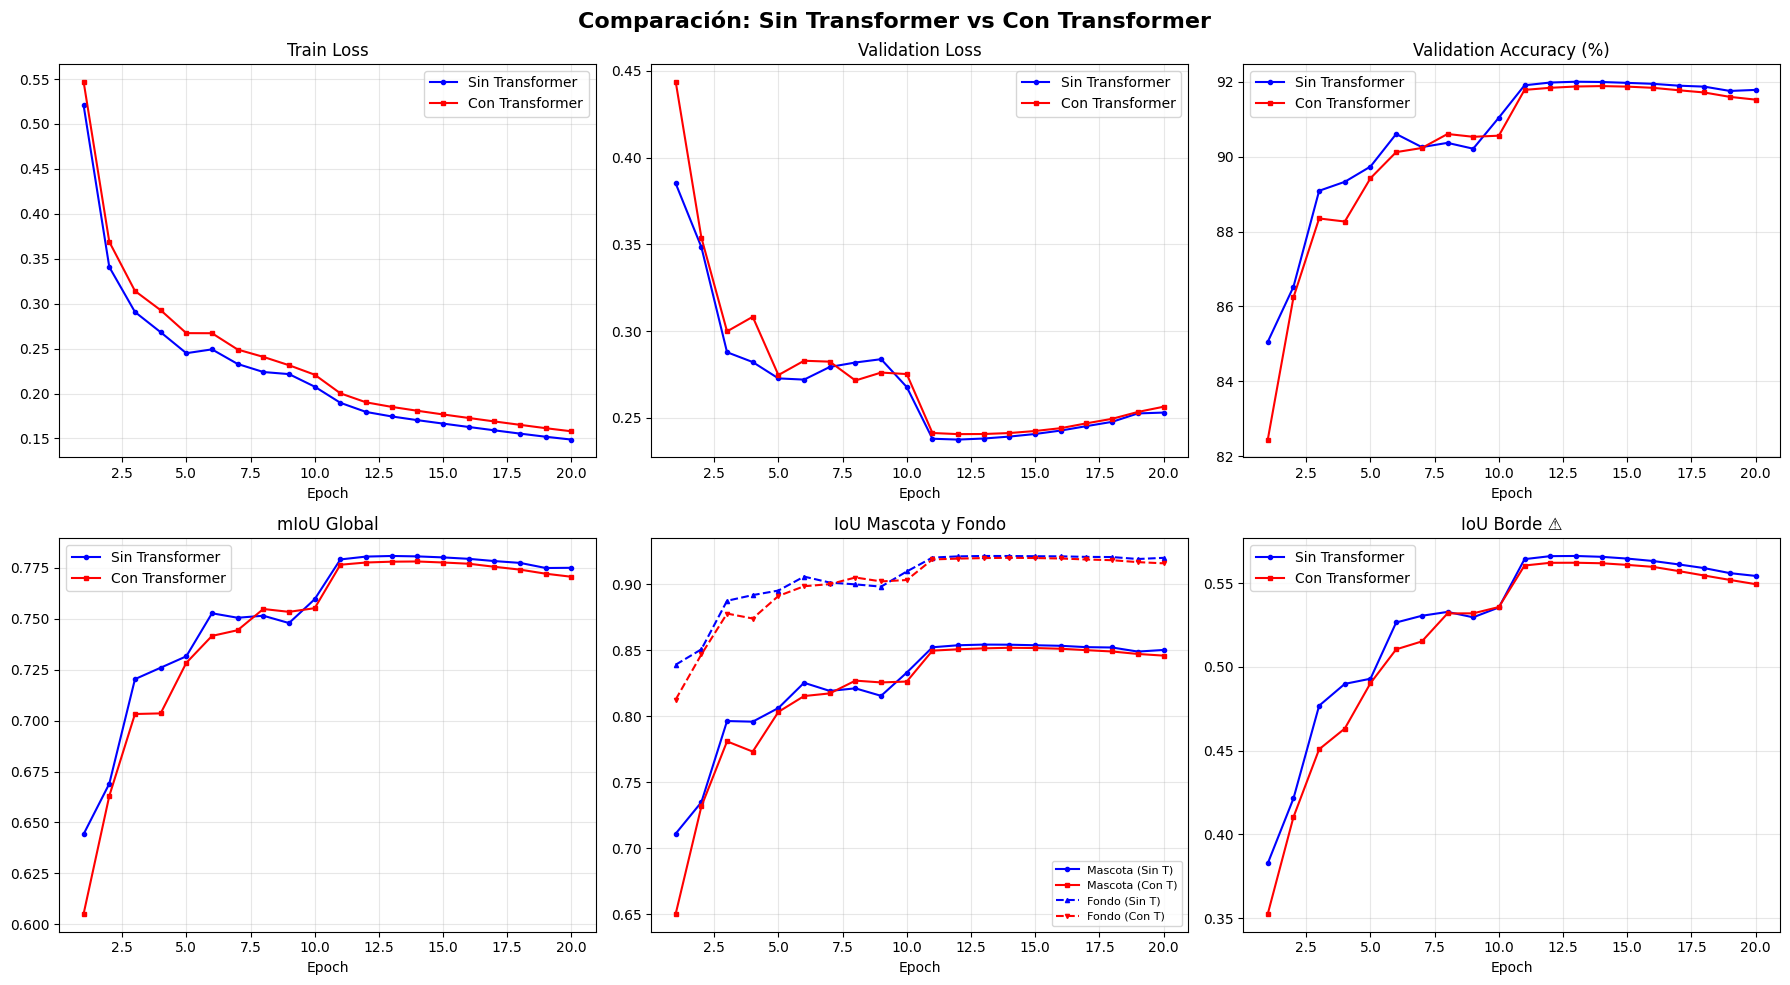


RESUMEN COMPARATIVO (mejor epoch de cada modelo)
Métrica                      Sin Transformer    Con Transformer
---------------------------------------------------------------
Mejor epoch                               13                 14
Val Loss                              0.2382             0.2413
Val Accuracy                          92.01%             91.89%
mIoU Global                           0.7807             0.7780
IoU Mascota                           0.8544             0.8519
IoU Fondo                             0.9215             0.9202
IoU Borde                             0.5662             0.5619


In [38]:
comparar_entrenamientos(
    'logs/training_history2026-03-04.csv',      # Sin transformer
    'logs/training_history2026-03-04_2.csv'      # Con transformer
)